# Index Fund Construction: Reproducible Project Demo

We track monthly value-weighted and equally weighted indexes of the **500 largest
eligible stocks** using **25, 50, and 100 candidates**. For each index and size, we
compare representative cluster-mass weights with optimized tracking-error weights:
**12 strategies** per holding month.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import time
import numpy as np
import pandas as pd
import scipy
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.optimize import minimize
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
DATA_DIR = ROOT / "top500_data"
OUTPUT_DIR = ROOT / "demo_output"
USE_LOCAL_CACHE = True
DATA_START = "1995-01"
DATA_END = "2025-12"
START_HOLDING = "2000-01"
END_HOLDING = "2025-12"
N_STOCKS = 500
LOOKBACK = 60
K_VALUES = (25, 50, 100)
MIN_TRAINING_MONTHS = 36
MISSING_BENCHMARK = "drop"
OBJECTIVE = "tracking_error"
MAX_WEIGHT = 1.0
RIDGE = 0.0
BENCHMARKS = ("value_weighted", "equal_weighted")
METHODS = ("representative", "optimized")
STRATEGY_KEYS = ["k", "benchmark", "method"]
PORTFOLIO_KEYS = ["holding_month"] + STRATEGY_KEYS

data_start, data_end = pd.Period(DATA_START, "M"), pd.Period(DATA_END, "M")
holding_start, holding_end = pd.Period(START_HOLDING, "M"), pd.Period(END_HOLDING, "M")
if holding_end < holding_start or holding_end > data_end:
    raise ValueError("Holding period must be ordered and supported by DATA_END")
if data_start > holding_start - LOOKBACK:
    raise ValueError("DATA_START must cover the full stock-selection training window")
if len(set(K_VALUES)) != len(K_VALUES) or not all(2 <= k < N_STOCKS for k in K_VALUES):
    raise ValueError("Choose distinct candidate counts between 2 and N_STOCKS-1")
if not 2 <= MIN_TRAINING_MONTHS <= LOOKBACK:
    raise ValueError("Invalid minimum training count")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
print(f"Holdings: {START_HOLDING} to {END_HOLDING}; "
      f"{len(K_VALUES) * len(BENCHMARKS) * len(METHODS)} strategies per month")

Holdings: 2000-01 to 2025-12; 12 strategies per month


## Part 1. CRSP extraction and benchmark universe

Use `msf_v2` and the security-information history at each observation date.
Eligible constituents are U.S. common corporate equities on NYSE, AMEX, or
NASDAQ. Rank eligible securities by month-end capitalization, breaking ties by
PERMNO. Keep **every available month for each stock ever selected**, including
months after it leaves the top 500. This preserves returns on lagged holdings.

The source query, eligibility rule, and monthly ranking match the supplied
extraction. Coverage flags count observed prices and returns in a rolling
60-month calendar window. Missing months count as missing observations.

In [2]:
def parse_flag(series):
    values = series.astype(str).str.lower().map(
        {"true": True, "false": False, "1": True, "0": False}
    )
    if values.isna().any():
        raise ValueError("Unrecognized boolean coverage flag in cached formations")
    return values.astype(bool)


def validate_source_tables(formations, history):
    for frame, required in [
        (formations, {"month", "permno", "mthcap", "has_60_returns"}),
        (history, {"month", "permno", "mthret", "mthprc"}),
    ]:
        if not required.issubset(frame.columns):
            raise ValueError(f"Source table is missing {sorted(required - set(frame.columns))}")
        if frame[["month", "permno"]].isna().any().any() or frame.duplicated(["month", "permno"]).any():
            raise ValueError("Null or duplicate stock-month keys")
    calendar = pd.period_range(data_start, data_end, freq="M")
    counts = formations.groupby("month").size().reindex(calendar)
    if not counts.eq(N_STOCKS).all():
        raise ValueError("Source cache does not contain the configured monthly universe")
    if history["month"].min() > data_start or history["month"].max() < data_end:
        raise ValueError("Source history does not cover the configured data period")
    caps = formations["mthcap"].to_numpy(dtype=float)
    if not np.isfinite(caps).all() or (caps <= 0).any():
        raise ValueError("Invalid formation market capitalization")


formation_path = DATA_DIR / "top500_formations.csv"
history_path = DATA_DIR / "selected_stock_monthly_history.csv"
if USE_LOCAL_CACHE and formation_path.is_file() and history_path.is_file():
    formations = pd.read_csv(formation_path)
    history = pd.read_csv(history_path)
    for frame in (formations, history):
        frame["month"] = pd.PeriodIndex(frame["month"], freq="M")
    formations = formations.loc[formations["month"].between(data_start, data_end)].copy()
    history = history.loc[history["month"].between(data_start, data_end)].copy()
    for name in ["has_60_prices", "has_60_returns"]:
        if name in formations:
            formations[name] = parse_flag(formations[name])
    for frame, columns in [(formations, ["mthcap"]), (history, ["mthret", "mthprc"])]:
        for name in columns:
            frame[name] = pd.to_numeric(frame[name], errors="coerce")
    source_mode = "local extraction cache"
else:
    try:
        import wrds
    except ImportError as exc:
        raise ImportError("Install wrds using the optional setup cell and rerun") from exc
    START = str(data_start.start_time.date())
    END_EXCLUSIVE = str((data_end + 1).start_time.date())
    query = f"""
    SELECT m.permno, m.mthcaldt, m.mthprc, m.mthret, m.shrout, m.mthcap,
           EXISTS (
               SELECT 1 FROM crsp.stksecurityinfohist AS s
               WHERE s.permno = m.permno
                 AND m.mthcaldt BETWEEN s.secinfostartdt AND s.secinfoenddt
                 AND s.sharetype = 'NS' AND s.securitytype = 'EQTY'
                 AND s.securitysubtype = 'COM' AND s.usincflg = 'Y'
                 AND s.issuertype IN ('ACOR', 'CORP')
                 AND s.primaryexch IN ('N', 'A', 'Q')
           ) AS is_eligible
    FROM crsp.msf_v2 AS m
    WHERE m.mthcaldt >= '{START}' AND m.mthcaldt < '{END_EXCLUSIVE}'
    """
    print("Connecting to WRDS; authenticate with your own account.")
    conn = wrds.Connection()
    try:
        crsp = conn.raw_sql(query)
    finally:
        conn.close()
    crsp["month"] = pd.to_datetime(crsp["mthcaldt"]).dt.to_period("M")
    for name in ["mthprc", "mthret", "shrout", "mthcap"]:
        crsp[name] = pd.to_numeric(crsp[name], errors="coerce")
    crsp["is_eligible"] = parse_flag(crsp["is_eligible"])
    formations = (
        crsp.loc[crsp["is_eligible"] & crsp["mthcap"].gt(0),
                 ["month", "permno", "mthcap", "mthprc"]]
        .sort_values(["month", "mthcap", "permno"], ascending=[True, False, True])
        .groupby("month", sort=False).head(N_STOCKS).copy()
    )
    formations["weight"] = formations["mthcap"] / formations.groupby("month")["mthcap"].transform("sum")
    selected_permnos = formations["permno"].unique()
    history = crsp.loc[crsp["permno"].isin(selected_permnos),
                       ["month", "permno", "mthprc", "mthret"]].copy()
    del crsp
    source_mode = "WRDS query"

# Recompute flags even when reading cache; do not trust flags from another lookback.
all_months = pd.period_range(data_start, data_end, freq="M")
selected_permnos = formations["permno"].unique()
if history.duplicated(["month", "permno"]).any():
    raise ValueError("Duplicate history keys before pivot")
price_grid = history.pivot(index="month", columns="permno", values="mthprc").reindex(
    index=all_months, columns=selected_permnos
)
return_grid = history.pivot(index="month", columns="permno", values="mthret").reindex(
    index=all_months, columns=selected_permnos
)
for name, observed in [
    ("n_price_months", price_grid.notna() & price_grid.ne(0)),
    ("n_return_months", return_grid.notna()),
]:
    counts = observed.rolling(LOOKBACK, min_periods=1).sum()
    counts.index.name, counts.columns.name = "month", "permno"
    lookup = counts.stack().rename(name)
    keys = pd.MultiIndex.from_frame(formations[["month", "permno"]])
    formations[name] = lookup.reindex(keys).to_numpy()
formations["has_60_prices"] = formations["n_price_months"].eq(LOOKBACK)
formations["has_60_returns"] = formations["n_return_months"].eq(LOOKBACK)
validate_source_tables(formations, history)
for frame, path in [(formations, formation_path), (history, history_path)]:
    saved = frame.copy()
    saved["month"] = saved["month"].astype(str)
    saved.to_csv(path, index=False)
del price_grid, return_grid
print(f"Source: {source_mode}; {len(formations):,} formation rows; {len(history):,} history rows")
display(formations.head())
display(history.head())

Source: local extraction cache; 186,000 formation rows; 392,863 history rows


,month,permno,mthcap,mthprc,weight,n_price_months,n_return_months,has_60_prices,has_60_returns
0,1995-01,12060,88047490.00,51.500,0.024625,1.0,1.0,False,False
1,1995-01,10401,77956919.25,49.875,0.021803,1.0,1.0,False,False
2,1995-01,11850,77591000.00,62.500,0.021701,1.0,1.0,False,False
3,1995-01,11308,67501350.00,52.500,0.018879,1.0,1.0,False,False
4,1995-01,55976,52571874.00,22.875,0.014704,1.0,1.0,False,False


,month,permno,mthprc,mthret
0,1995-01,10078,32.750,-0.077465
1,1995-01,10104,42.625,-0.033994
2,1995-01,10107,59.375,-0.028630
3,1995-01,10108,35.750,-0.071429
4,1995-01,10137,24.000,0.103448


In [3]:
coverage_summary = formations.loc[
    formations["month"].between(holding_start - 1, holding_end - 1)
].groupby("month").agg(
    n_stocks=("permno", "size"),
    n_with_full_prices=("has_60_prices", "sum"),
    n_with_full_returns=("has_60_returns", "sum"),
)
coverage_summary.to_csv(OUTPUT_DIR / "source_history_coverage.csv")
display(coverage_summary.head())
print("Months with a complete history for every benchmark constituent:",
      int(coverage_summary["n_with_full_returns"].eq(N_STOCKS).sum()))

,n_stocks,n_with_full_prices,n_with_full_returns
month,,,
1999-12,500,382,382
2000-01,500,379,379
2000-02,500,360,360
2000-03,500,369,369
2000-04,500,383,383


Months with a complete history for every benchmark constituent: 0


## Part 2. Correlation clustering and representative selection

At formation month-end $t$, retain current index constituents with complete stock
returns over $t-59,\ldots,t$. Compute $d_{ij}=1-\rho_{ij}$, apply average-linkage
hierarchical clustering, and select the medoid of each cluster (the stock with
smallest average within-cluster distance). Run the same selection for each $k$.
Use only formation-time data. Keep the full 500-stock benchmark for evaluation.

Some benchmark constituents have insufficient history and are excluded from
clustering. This changes the eligible selection universe, not the target index.
The weighting stage reports the eligible share of benchmark mass.

In [4]:
def choose_cluster_representatives(clusters, distance_matrix):
    
    representatives = []

    for cluster_id, group in clusters.groupby("cluster"):
        
        members = group["permno"].tolist()

        # If the cluster only contains one stock,
        # that stock is automatically the representative
        if len(members) == 1:
            representative = members[0]

        else:
            cluster_distances = distance_matrix.loc[
                members, members
            ]

            average_distance = cluster_distances.mean(axis=1)

            representative = average_distance.idxmin()

        representatives.append({
            "cluster": cluster_id,
            "representative_permno": representative,
            "cluster_size": len(members)
        })

    return pd.DataFrame(representatives)

def select_representatives_for_k(
    Z,
    corr_matrix,
    distance_matrix,
    k
):
    
    labels = fcluster(
        Z,
        t=k,
        criterion="maxclust"
    )

    clusters = pd.DataFrame({
        "permno": corr_matrix.columns,
        "cluster": labels
    })

    representatives = choose_cluster_representatives(
        clusters,
        distance_matrix
    )

    representatives["k"] = k

    return clusters, representatives

In [5]:
def cluster_one_month(
    formation_month,
    formations,
    history,
    k_values=(25, 50, 100),
    lookback=60,
    expected_n=500
):
    
    # --------------------------------------------------
    # 1. Current top-500 universe
    # --------------------------------------------------
    
    current_universe = formations[
        formations["month"] == formation_month
    ].copy()

    if len(current_universe) != expected_n:
        raise ValueError(
            f"{formation_month}: expected {expected_n} stocks, "
            f"found {len(current_universe)}"
        )

    
    # --------------------------------------------------
    # 2. Stocks with full 60-month return history
    # --------------------------------------------------
    
    eligible = current_universe[
        current_universe["has_60_returns"]
    ].copy()

    eligible_permnos = eligible["permno"].tolist()

    
    # --------------------------------------------------
    # 3. Previous 60 months of returns
    # --------------------------------------------------
    
    start_month = formation_month - (lookback - 1)

    window = history[
        (history["month"] >= start_month) &
        (history["month"] <= formation_month) &
        (history["permno"].isin(eligible_permnos))
    ].copy()

    return_matrix = window.pivot(
        index="month",
        columns="permno",
        values="mthret"
    ).sort_index()

    
    # --------------------------------------------------
    # 4. Sanity checks
    # --------------------------------------------------
    
    if return_matrix.shape[0] != lookback:
        raise ValueError(
            f"{formation_month}: expected {lookback} months, "
            f"found {return_matrix.shape[0]}"
        )

    if return_matrix.isna().any().any():
        raise ValueError(
            f"{formation_month}: missing returns remain"
        )

    
    # --------------------------------------------------
    # 5. Correlations
    # --------------------------------------------------
    
    if return_matrix.shape[1] < max(k_values):
        raise ValueError(f"{formation_month}: fewer eligible stocks than the largest k")
    values = return_matrix.to_numpy(dtype=float)
    if not np.isfinite(values).all() or (values < -1).any():
        raise ValueError(f"{formation_month}: invalid stock returns")
    corr_matrix = return_matrix.corr()
    if not np.isfinite(corr_matrix.to_numpy()).all():
        raise ValueError(f"{formation_month}: undefined correlations")

    
    # --------------------------------------------------
    # 6. Convert correlation into distance
    # --------------------------------------------------
    
    distance_array = np.array(
    1 - corr_matrix,
    dtype=float,
    copy=True
    )
    
    distance_array = np.clip(
        distance_array,
        0,
        None
    )
    
    np.fill_diagonal(
        distance_array,
        0.0
    )
    
    distance_matrix = pd.DataFrame(
        distance_array,
        index=corr_matrix.index,
        columns=corr_matrix.columns
    )

    
    # --------------------------------------------------
    # 7. Hierarchical clustering
    # --------------------------------------------------
    
    condensed_distance = squareform(
        distance_array,
        checks=False
    )

    Z = linkage(
        condensed_distance,
        method="average"
    )

    
    # --------------------------------------------------
    # 8. Select representatives for each k
    # --------------------------------------------------
    
    outputs = []

    for k in k_values:

        labels = fcluster(
            Z,
            t=k,
            criterion="maxclust"
        )

        clusters = pd.DataFrame({
            "permno": corr_matrix.columns,
            "cluster": labels
        })

        representatives = choose_cluster_representatives(
            clusters,
            distance_matrix
        )

        if len(representatives) != k:
            raise ValueError(f"{formation_month}: clustering produced fewer than {k} clusters")
        representatives["month"] = formation_month
        representatives["k"] = k

        outputs.append(representatives)

    
    representatives_all = pd.concat(
        outputs,
        ignore_index=True
    )

    return representatives_all

In [6]:
formation_months = pd.period_range(holding_start - 1, holding_end - 1, freq="M")
all_results = []
selection_started = time.perf_counter()
for i, month in enumerate(formation_months):
    all_results.append(cluster_one_month(
        month, formations, history, k_values=K_VALUES,
        lookback=LOOKBACK, expected_n=N_STOCKS,
    ))
    if i == 0 or (i + 1) % 25 == 0 or i + 1 == len(formation_months):
        print(f"Selection: {i + 1}/{len(formation_months)} formation months")
selections = pd.concat(all_results, ignore_index=True)
selection_check = selections.groupby(["month", "k"])["representative_permno"].nunique().unstack()
for k in K_VALUES:
    if not selection_check[k].eq(k).all():
        raise ValueError(f"Incorrect number of representatives for k={k}")
saved_selections = selections.copy()
saved_selections["month"] = saved_selections["month"].astype(str)
saved_selections.to_csv(OUTPUT_DIR / "cluster_selected_stocks.csv", index=False)
display(selection_check.head())
display(selections.head())
print(f"Selection completed in {time.perf_counter() - selection_started:.1f} seconds")

Selection: 1/312 formation months
Selection: 25/312 formation months
Selection: 50/312 formation months
Selection: 75/312 formation months
Selection: 100/312 formation months
Selection: 125/312 formation months
Selection: 150/312 formation months
Selection: 175/312 formation months
Selection: 200/312 formation months
Selection: 225/312 formation months
Selection: 250/312 formation months
Selection: 275/312 formation months
Selection: 300/312 formation months
Selection: 312/312 formation months


k,25,50,100
month,,,
1999-12,25,50,100
2000-01,25,50,100
2000-02,25,50,100
2000-03,25,50,100
2000-04,25,50,100


,cluster,representative_permno,cluster_size,month,k
0,1,63773,6,1999-12,25
1,2,43610,2,1999-12,25
2,3,58990,1,1999-12,25
3,4,66093,9,1999-12,25
4,5,49680,6,1999-12,25


Selection completed in 14.4 seconds


## Part 3. Benchmark construction and portfolio weights

Both benchmarks use **previous month-end holdings**, not the realized month's
constituents:

$$b^{VW}_{i,t}=\frac{M_{i,t}}{\sum_{j\in U_t}M_{j,t}},\qquad
b^{EW}_{i,t}=\frac{1}{500},\qquad
r^B_{t+1}=\sum_{i\in U_t}b_{i,t}r_{i,t+1}.$$

A missing or invalid benchmark-constituent return invalidates that whole month's
index return. No zero filling or survivor reweighting is used. The first
computable benchmark return is February 1995 because December 1994 holdings are
not downloaded. January 1995 is explicitly recorded as missing in the first fit.

**Representative weighting:** assign each medoid the benchmark mass of its
eligible cluster, then normalize over all eligible clusters:

$$w^{rep}_{j,t}=\frac{\sum_{i\in C_j}b_{i,t}}{\sum_{i\in E_t}b_{i,t}}.$$

This is cluster capitalization for the value-weighted index and cluster size
for the equal-weighted index. It need not give equal weights to medoids.

**Optimized weighting:** on the usable observations of the trailing 60-month
window, solve

$$\min_w\frac{1}{T-1}\sum_{s=1}^T
\left[(Xw-y)_s-\overline{Xw-y}\right]^2,
\qquad \mathbf{1}^{\top}w=1,\quad 0\leq w_j\leq u.$$

The default is tracking-error variance, $u=1$, and no ridge penalty. The optional
`mse` objective penalizes average tracking difference as well; positive `RIDGE`
shrinks toward representative weights. At $k=100$ with at most 60 observations,
unregularized solutions can be nonunique. SciPy SLSQP uses analytic gradients,
without covariance inversion, and stops if optimization or feasibility checks fail.
Some candidate weights can be zero.

Stock selection uses all 60 stock observations. Optimization drops incomplete
benchmark dates within that same window and requires at least **36** complete
observations, matching the supplied weighting policy. Excluded training dates,
actual sample sizes, concentration, and eligible benchmark mass are exported.
Missing future returns remain missing.

In [7]:
def prepare_inputs(formations, history, selections):
    """Copy, normalize dates, and check the three existing CSV schemas."""
    specs = [
        (formations, ['month', 'permno', 'mthcap'], ['month', 'permno']),
        (history, ['month', 'permno', 'mthret'], ['month', 'permno']),
        (
            selections,
            ['month', 'k', 'cluster', 'representative_permno', 'cluster_size'],
            ['month', 'k', 'cluster'],
        ),
    ]
    result = []
    for frame, required, keys in specs:
        missing = set(required) - set(frame.columns)
        if missing:
            raise ValueError(f'Missing required columns: {sorted(missing)}')
        frame = frame.copy()
        frame['month'] = pd.PeriodIndex(frame['month'], freq='M')
        if frame[keys].isna().any().any() or frame.duplicated(keys).any():
            raise ValueError(f'Null or duplicate keys: {keys}')
        result.append(frame)
    return tuple(result)

def build_benchmark_returns(formations, history, expected_n=500):
    """Full-universe benchmark returns, using prior month-end holdings.

    Missing constituent returns invalidate the entire benchmark month. They
    are never filled with zero or dropped and reweighted. Return coverage is
    exported so the preceding stage can resolve any missing/delisting observations.
    """
    last_month = history['month'].max()
    holdings = formations.loc[
        formations['month'] + 1 <= last_month, ['month', 'permno', 'mthcap']
    ].copy()
    holdings['month'] = holdings['month'] + 1
    joined = holdings.merge(
        history[['month', 'permno', 'mthret']],
        on=['month', 'permno'],
        how='left',
        validate='one_to_one',
    )
    rows = []
    for month, group in joined.groupby('month', sort=True):
        caps = group['mthcap'].to_numpy(dtype=float)
        returns = group['mthret'].to_numpy(dtype=float)
        if len(group) != expected_n or not np.isfinite(caps).all() or (caps <= 0).any():
            raise ValueError(f'{month}: invalid benchmark universe/capitalizations')
        valid = np.isfinite(returns) & (returns >= -1)
        complete = valid.all()
        rows.append({
            'month': month,
            'formation_month': month - 1,
            'n_stocks': len(group),
            'n_missing_returns': int((~valid).sum()),
            'value_weighted': float(caps @ returns / caps.sum()) if complete else np.nan,
            'equal_weighted': float(returns.mean()) if complete else np.nan,
        })
    if not rows:
        raise ValueError('No holding months overlap the exported history')
    return pd.DataFrame(rows).set_index('month')

def reconstruct_clusters(
    formation_month, formations, history, selections, lookback=60, expected_n=500
):
    """Reproduce Part 2's average-linkage clustering and check its saved CSV.

    Membership is needed to sum capitalization within each cluster; cluster
    size and the representative's own capitalization alone are insufficient.
    """
    month = pd.Period(formation_month, freq='M')
    universe = formations.loc[formations['month'].eq(month)].set_index('permno')
    if len(universe) != expected_n or not universe.index.is_unique:
        raise ValueError(f'{month}: expected {expected_n} unique universe stocks')
    caps = universe['mthcap'].to_numpy(dtype=float)
    if not np.isfinite(caps).all() or (caps <= 0).any():
        raise ValueError(f'{month}: invalid market capitalization')
    calendar = pd.period_range(month - lookback + 1, month, freq='M')
    window = history.loc[
        history['month'].isin(calendar) & history['permno'].isin(universe.index)
    ]
    returns = window.pivot(index='month', columns='permno', values='mthret')
    returns = returns.reindex(index=calendar, columns=sorted(universe.index))
    returns = returns.loc[:, returns.notna().all()]
    values = returns.to_numpy(dtype=float)
    if returns.shape[1] < 2 or not np.isfinite(values).all() or (values < -1).any():
        raise ValueError(f'{month}: invalid eligible return history')
    corr = returns.corr().to_numpy()
    if not np.isfinite(corr).all():
        raise ValueError(f'{month}: undefined correlations (check constant returns)')
    distance = np.clip(1 - corr, 0, None)
    np.fill_diagonal(distance, 0)
    tree = linkage(squareform(distance, checks=False), method='average')
    saved = selections.loc[selections['month'].eq(month)]
    if saved.empty:
        raise ValueError(f'{month}: no saved representatives')
    memberships = []
    for k, selected in saved.groupby('k', sort=True):
        labels = fcluster(tree, t=int(k), criterion='maxclust')
        members = pd.DataFrame({'permno': returns.columns, 'cluster': labels})
        if len(selected) != k or members['cluster'].nunique() != k:
            raise ValueError(f'{month}, k={k}: expected exactly k clusters')
        reconstructed = []
        for cluster, group in members.groupby('cluster'):
            positions = returns.columns.get_indexer(group['permno'])
            mean_distances = distance[np.ix_(positions, positions)].mean(axis=1)
            medoid = group['permno'].iloc[np.argmin(mean_distances)]
            reconstructed.append((cluster, medoid, len(group)))
        actual = pd.DataFrame(
            reconstructed,
            columns=['cluster', 'representative_permno', 'cluster_size'],
        ).sort_values('cluster')
        expected = selected[actual.columns].sort_values('cluster')
        if not np.array_equal(actual.to_numpy(), expected.to_numpy()):
            raise ValueError(
                f'{month}, k={k}: clustering does not match selection table; '
                'use the original data/SciPy environment or export '
                'memberships from Part 2'
            )
        members['k'] = int(k)
        memberships.append(members)
    return universe, returns, pd.concat(memberships, ignore_index=True)

In [8]:
def representative_weights(universe, members, selected, benchmark):
    """Sum eligible benchmark mass by cluster, then normalize to invest 100%.

    Coverage is measured against the full universe before normalization.
    Excluded stocks have no cluster in Part 2 and cannot be represented here.
    """
    if benchmark == 'value_weighted':
        base = universe['mthcap'] / universe['mthcap'].sum()
    elif benchmark == 'equal_weighted':
        base = pd.Series(1 / len(universe), index=universe.index)
    else:
        raise ValueError('Unknown benchmark')
    members = members.copy()
    members['mass'] = members['permno'].map(base)
    if members['mass'].isna().any() or members['permno'].duplicated().any():
        raise ValueError('Invalid cluster membership')
    masses = members.groupby('cluster')['mass'].sum()
    selected = selected.sort_values('cluster')
    weights = selected['cluster'].map(masses).to_numpy(dtype=float)
    coverage = float(masses.sum())
    if (
        not np.isfinite(weights).all()
        or coverage <= 0
        or not np.isclose(weights.sum(), coverage)
    ):
        raise ValueError('Representatives do not cover all eligible clusters')
    weights = pd.Series(
        weights / coverage,
        index=selected['representative_permno'].to_numpy(),
        name='weight',
    )
    return weights, coverage

def fit_tracking_weights(
    returns, benchmark_returns, initial_weights,
    objective='tracking_error', max_weight=1.0, ridge=0.0,
):
    """Constrained quadratic fit, without covariance inversion.

    tracking_error minimizes sample variance of active returns; mse also
    penalizes their mean. Optional ridge shrinks toward representative weights.
    The default ridge=0 is the exact unregularized assignment objective.
    """
    if objective not in ('tracking_error', 'mse'):
        raise ValueError('objective must be tracking_error or mse')
    if not returns.index.equals(benchmark_returns.index):
        raise ValueError('Stock and benchmark months must match exactly')
    if (
        not returns.columns.is_unique
        or not returns.index.is_unique
        or not initial_weights.index.is_unique
    ):
        raise ValueError('Duplicate stock or month labels')
    target = initial_weights.reindex(returns.columns).to_numpy(dtype=float)
    x = returns.to_numpy(dtype=float)
    y = benchmark_returns.to_numpy(dtype=float)
    if len(y) < 2 or not np.isfinite(x).all() or not np.isfinite(y).all():
        raise ValueError('Need at least two complete, finite training months')
    if (
        not np.isfinite(target).all()
        or (target < 0).any()
        or not np.isclose(target.sum(), 1)
    ):
        raise ValueError('Initial weights must be long-only and sum to one')
    k = x.shape[1]
    if (
        not np.isfinite(max_weight)
        or not 0 < max_weight <= 1
        or k * max_weight < 1 - 1e-12
    ):
        raise ValueError('Infeasible maximum weight: require k * max_weight >= 1')
    if not np.isfinite(ridge) or ridge < 0:
        raise ValueError('ridge must be finite and nonnegative')
    if objective == 'tracking_error':
        x = x - x.mean(axis=0)
        y = y - y.mean()
        denominator = len(y) - 1
    else:
        denominator = len(y)
    # Scale the entire objective to help SLSQP handle decimal monthly returns.
    scale = max(float(np.mean(x * x)), float(np.mean(y * y)), ridge, 1e-8)

    def loss(w):
        error = x @ w - y
        penalty = ridge * np.sum((w - target) ** 2)
        return (error @ error / denominator + penalty) / scale

    def gradient(w):
        tracking_gradient = 2 * x.T @ (x @ w - y) / denominator
        return (tracking_gradient + 2 * ridge * (w - target)) / scale

    start = target.copy() if target.max() <= max_weight else np.full(k, 1 / k)
    result = minimize(
        loss,
        start,
        jac=gradient,
        method='SLSQP',
        bounds=[(0, max_weight)] * k,
        constraints=[{
            'type': 'eq',
            'fun': lambda w: w.sum() - 1,
            'jac': lambda w: np.ones(k),
        }],
        options={'ftol': 1e-11, 'maxiter': 2000},
    )
    w = result.x
    if (
        not result.success
        or not np.isfinite(w).all()
        or abs(w.sum() - 1) > 1e-7
        or w.min() < -1e-8
        or w.max() > max_weight + 1e-8
        or loss(w) > loss(start) + 1e-8
    ):
        raise RuntimeError(f'Weight optimization failed: {result.message}')
    # Remove only floating-point bound noise, then recheck feasibility.
    w = np.clip(w, 0, max_weight)
    w /= w.sum()
    if w.max() > max_weight + 1e-8:
        raise RuntimeError('Maximum weight violated after numerical cleanup')
    return pd.Series(w, index=returns.columns, name='weight'), {
        'solver_message': str(result.message),
        'solver_iterations': int(result.nit),
    }

def _tracking_diagnostics(stock_returns, benchmark_returns, weights):
    """Calculate fitted tracking metrics for one portfolio."""
    active = stock_returns @ weights - benchmark_returns
    return {
        'n_positive_weights': int((weights > 1e-8).sum()),
        'max_weight': float(weights.max()),
        'in_sample_te_annualized': float(active.std(ddof=1) * np.sqrt(12)),
        'in_sample_mean_active_monthly': float(active.mean()),
        'in_sample_rmse_monthly': float(np.sqrt(np.mean(active ** 2))),
    }

In [9]:
def weight_one_month(
    formation_month, formations, history, selections, benchmarks,
    lookback=60, expected_n=500, objective='tracking_error',
    max_weight=1.0, ridge=0.0, missing_benchmark='raise', min_training_months=48,
):
    """Return long-format weights and in-sample diagnostics for both benchmarks.

    By default an incomplete benchmark window fails. With missing_benchmark
    set to 'drop', fit only complete benchmark months within the same lookback
    window, require min_training_months, and record all exclusions. Stock
    selection still requires the full history. No t+1 returns are used.
    """
    month = pd.Period(formation_month, freq='M')
    calendar = pd.period_range(month - lookback + 1, month, freq='M')
    training = benchmarks.reindex(calendar)[list(BENCHMARKS)]
    complete_months = np.isfinite(training.to_numpy(dtype=float)).all(axis=1)
    bad = training.index[~complete_months].astype(str).tolist()
    if missing_benchmark not in ('raise', 'drop'):
        raise ValueError("missing_benchmark must be 'raise' or 'drop'")
    if missing_benchmark == 'raise' and bad:
        raise ValueError(f'{month}: incomplete benchmark training window: {bad}')
    if missing_benchmark == 'drop':
        if not 2 <= min_training_months <= lookback:
            raise ValueError('Require 2 <= min_training_months <= lookback')
        training = training.loc[complete_months]
        if len(training) < min_training_months:
            raise ValueError(
                f'{month}: only {len(training)} complete benchmark months; '
                f'require at least {min_training_months}'
            )
    universe, returns, memberships = reconstruct_clusters(
        month, formations, history, selections, lookback, expected_n
    )
    weight_rows, diagnostic_rows = [], []
    monthly_selections = selections.loc[selections['month'].eq(month)]
    for k, members in memberships.groupby('k', sort=True):
        selected = monthly_selections.loc[monthly_selections['k'].eq(k)]
        for benchmark in BENCHMARKS:
            representative, coverage = representative_weights(
                universe, members, selected, benchmark
            )
            x = returns.loc[training.index, representative.index]
            y = training[benchmark]
            optimized, solver = fit_tracking_weights(
                x, y, representative,
                objective=objective, max_weight=max_weight, ridge=ridge,
            )
            methods = {'representative': representative, 'optimized': optimized}
            for method, weights in methods.items():
                is_optimized = method == 'optimized'
                keys = {
                    'formation_month': str(month),
                    'holding_month': str(month + 1),
                    'k': int(k),
                    'benchmark': benchmark,
                    'method': method,
                }
                for permno, weight in weights.items():
                    weight_rows.append({
                        **keys, 'permno': int(permno), 'weight': float(weight),
                    })
                diagnostic_rows.append({
                    **keys,
                    'training_start': str(calendar[0]),
                    'training_end': str(month),
                    'n_training_months': len(training),
                    'missing_benchmark_policy': missing_benchmark,
                    'n_excluded_training_months': len(bad),
                    'excluded_training_months': ';'.join(bad),
                    'n_eligible': returns.shape[1],
                    'benchmark_mass_covered': coverage,
                    **_tracking_diagnostics(x, y, weights),
                    'objective': objective if is_optimized else 'cluster_mass',
                    'ridge': ridge if is_optimized else 0.0,
                    'weight_cap': max_weight if is_optimized else 1.0,
                    'solver_message': (
                        solver['solver_message'] if is_optimized else 'not applicable'
                    ),
                })
    return pd.DataFrame(weight_rows), pd.DataFrame(diagnostic_rows)

In [10]:
formations, history, selections = prepare_inputs(formations, history, selections)
benchmarks = build_benchmark_returns(formations, history, expected_n=N_STOCKS)
display(benchmarks.head())
print("Incomplete benchmark months (source period):", int(benchmarks["n_missing_returns"].gt(0).sum()))


def export_monthly_weights(formations, history, selections, benchmarks,
                           start, end, output_dir, **fit_options):
    """Generate all requested portfolios; failures stop rather than skip months."""
    calendar = pd.period_range(start, end, freq="M")
    weight_frames, diagnostic_frames = [], []
    started = time.perf_counter()
    for i, holding_month in enumerate(calendar):
        w, d = weight_one_month(
            holding_month - 1, formations, history, selections, benchmarks, **fit_options
        )
        expected_strategies = len(K_VALUES) * len(BENCHMARKS) * len(METHODS)
        if len(d) != expected_strategies:
            raise ValueError(f"{holding_month}: incomplete strategy set")
        weight_frames.append(w)
        diagnostic_frames.append(d)
        if i == 0 or (i + 1) % 25 == 0 or i + 1 == len(calendar):
            print(f"Weighting: {i + 1}/{len(calendar)} holding months; "
                  f"{time.perf_counter() - started:.1f} seconds")
    weights = pd.concat(weight_frames, ignore_index=True)
    diagnostics = pd.concat(diagnostic_frames, ignore_index=True)
    suffix = f"{start}_to_{end}.csv"
    weights.to_csv(output_dir / f"monthly_weights_{suffix}", index=False)
    diagnostics.to_csv(output_dir / f"monthly_weight_diagnostics_{suffix}", index=False)
    benchmarks.to_csv(output_dir / f"benchmark_returns_{suffix}")
    return weights, diagnostics


weights, weight_diagnostics = export_monthly_weights(
    formations, history, selections, benchmarks,
    start=START_HOLDING, end=END_HOLDING, output_dir=OUTPUT_DIR,
    lookback=LOOKBACK, expected_n=N_STOCKS, objective=OBJECTIVE,
    max_weight=MAX_WEIGHT, ridge=RIDGE,
    missing_benchmark=MISSING_BENCHMARK, min_training_months=MIN_TRAINING_MONTHS,
)
display(weight_diagnostics[[
    "holding_month", "k", "benchmark", "method", "n_training_months",
    "excluded_training_months", "benchmark_mass_covered", "n_positive_weights",
    "max_weight", "in_sample_te_annualized",
]].head(len(K_VALUES) * len(BENCHMARKS) * len(METHODS)))

,formation_month,n_stocks,n_missing_returns,value_weighted,equal_weighted
month,,,,,
1995-02,1995-01,500,1,NaN,NaN
1995-03,1995-02,500,0,0.026795,0.024733
1995-04,1995-03,500,0,0.028135,0.018692
1995-05,1995-04,500,0,0.038691,0.035192
1995-06,1995-05,500,0,0.026020,0.028372


Incomplete benchmark months (source period): 73
Weighting: 1/312 holding months; 0.2 seconds
Weighting: 25/312 holding months; 13.1 seconds
Weighting: 50/312 holding months; 27.7 seconds
Weighting: 75/312 holding months; 39.6 seconds
Weighting: 100/312 holding months; 51.3 seconds
Weighting: 125/312 holding months; 66.0 seconds
Weighting: 150/312 holding months; 82.5 seconds
Weighting: 175/312 holding months; 97.4 seconds
Weighting: 200/312 holding months; 108.2 seconds
Weighting: 225/312 holding months; 121.1 seconds
Weighting: 250/312 holding months; 133.6 seconds
Weighting: 275/312 holding months; 145.8 seconds
Weighting: 300/312 holding months; 154.8 seconds
Weighting: 312/312 holding months; 160.4 seconds


,holding_month,k,benchmark,method,n_training_months,excluded_training_months,benchmark_mass_covered,n_positive_weights,max_weight,in_sample_te_annualized
0,2000-01,25,value_weighted,representative,39,1995-01;1995-02;1995-12;1996-01;1996-04;1997-0...,0.867174,25,0.363980,1.192314e-01
1,2000-01,25,value_weighted,optimized,39,1995-01;1995-02;1995-12;1996-01;1996-04;1997-0...,0.867174,20,0.123808,4.015080e-02
2,2000-01,25,equal_weighted,representative,39,1995-01;1995-02;1995-12;1996-01;1996-04;1997-0...,0.764000,25,0.295812,8.007369e-02
3,2000-01,25,equal_weighted,optimized,39,1995-01;1995-02;1995-12;1996-01;1996-04;1997-0...,0.764000,21,0.137884,3.377633e-02
4,2000-01,50,value_weighted,representative,39,1995-01;1995-02;1995-12;1996-01;1996-04;1997-0...,0.867174,50,0.305080,1.042563e-01
5,2000-01,50,value_weighted,optimized,39,1995-01;1995-02;1995-12;1996-01;1996-04;1997-0...,0.867174,27,0.105357,1.728021e-02
6,2000-01,50,equal_weighted,representative,39,1995-01;1995-02;1995-12;1996-01;1996-04;1997-0...,0.764000,50,0.235602,6.216812e-02
7,2000-01,50,equal_weighted,optimized,39,1995-01;1995-02;1995-12;1996-01;1996-04;1997-0...,0.764000,32,0.122696,1.558262e-02
8,2000-01,100,value_weighted,representative,39,1995-01;1995-02;1995-12;1996-01;1996-04;1997-0...,0.867174,100,0.147488,6.621382e-02
9,2000-01,100,value_weighted,optimized,39,1995-01;1995-02;1995-12;1996-01;1996-04;1997-0...,0.867174,92,0.059282,7.452790e-07


## Part 4. Out-of-sample backtest and coverage audit

Apply weights formed at $t$ to realized returns in $t+1$. A missing positive-weight
stock return invalidates that portfolio observation; an exactly zero-weight row
does not require a return. Compare all 12 strategies on the same valid months.
Audit every requested month, including exclusions.

Turnover is the half-L1 distance from the prior portfolio's **drifted** weights,
aligned on the union of old and new PERMNOs:

$$\widetilde w_{i,t}=\frac{w_{i,t-1}(1+r_{i,t})}{1+r^P_t},\qquad
\operatorname{turnover}_t=\frac12\sum_i|w_{i,t}-\widetilde w_{i,t}|.$$

Exclude initial investment from average turnover. Missing prior portfolio
returns or absent prior holdings make turnover unavailable. Do not treat
separated valid months as consecutive investments. Realized returns are gross
of transaction costs, taxes, and fees. No delisting return is imputed: unresolved
missing returns are disclosed in the audit.

In [11]:
def normalize(frame, required, unique_keys, month_columns):
    """Normalize a handoff table without mutating the caller's data."""
    missing = set(required) - set(frame.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")
    frame = frame.copy()
    for name in month_columns:
        frame[name] = pd.PeriodIndex(frame[name], freq="M")
    if frame[list(unique_keys)].isna().any().any():
        raise ValueError(f"Null keys: {unique_keys}")
    if frame.duplicated(list(unique_keys)).any():
        raise ValueError(f"Duplicate keys: {unique_keys}")
    return frame

In [12]:
def evaluate_portfolios(weights, history, benchmarks, k_values=K_VALUES):
    """Evaluate saved t weights on t+1 returns; return observations and positions."""
    weights = normalize(
        weights,
        ["formation_month", "holding_month", "k", "benchmark", "method", "permno", "weight"],
        PORTFOLIO_KEYS + ["permno"], ["formation_month", "holding_month"],
    )
    history = normalize(history, ["month", "permno", "mthret"],
                        ["month", "permno"], ["month"])
    benchmarks = normalize(benchmarks, ["month"] + list(BENCHMARKS), ["month"], ["month"])
    if weights.empty:
        raise ValueError("No portfolio weights")
    if not weights["holding_month"].eq(weights["formation_month"] + 1).all():
        raise ValueError("Weights must apply exactly one month after formation")
    if not weights["k"].isin(k_values).all():
        raise ValueError("Unexpected candidate count k")
    if not weights["benchmark"].isin(BENCHMARKS).all() or not weights["method"].isin(METHODS).all():
        raise ValueError("Unexpected benchmark or weighting method")
    weights["weight"] = pd.to_numeric(weights["weight"], errors="raise")
    if not np.isfinite(weights["weight"]).all() or weights["weight"].lt(0).any():
        raise ValueError("Weights must be finite and nonnegative")
    checks = weights.groupby(PORTFOLIO_KEYS)["weight"].agg(["sum", "size"])
    if not np.allclose(checks["sum"], 1, rtol=0, atol=1e-7):
        raise ValueError("Portfolio weights must sum to one")
    if not np.array_equal(checks["size"], checks.index.get_level_values("k")):
        raise ValueError("Each portfolio must contain exactly k distinct candidates")
    # Normalize roundoff only after checking the exported weights.
    weights["weight"] /= weights.groupby(PORTFOLIO_KEYS)["weight"].transform("sum")
    history["mthret"] = pd.to_numeric(history["mthret"], errors="raise")
    for name in BENCHMARKS:
        benchmarks[name] = pd.to_numeric(benchmarks[name], errors="raise")

    positions = weights.merge(
        history.rename(columns={"month": "holding_month"})[["holding_month", "permno", "mthret"]],
        on=["holding_month", "permno"], how="left", validate="many_to_one",
    )
    positions["invalid_return"] = (
        positions["weight"].gt(0)
        & (~np.isfinite(positions["mthret"]) | positions["mthret"].lt(-1))
    )
    # Only the exactly zero-weight rows can safely have an unused missing return.
    positions["contribution"] = np.where(
        positions["weight"].eq(0), 0.0, positions["weight"] * positions["mthret"]
    )
    b = benchmarks.set_index("month")
    rows = []
    for keys, group in positions.groupby(PORTFOLIO_KEYS, sort=True):
        month, k, benchmark, method = keys
        bad = group.loc[group["invalid_return"], "permno"].tolist()
        rp = float(group["contribution"].sum()) if not bad else np.nan
        rb = float(b.loc[month, benchmark]) if month in b.index else np.nan
        valid_b = bool(np.isfinite(rb) and rb >= -1)
        reasons = []
        if bad:
            reasons.append("missing/invalid held-stock return")
        if not valid_b:
            reasons.append("missing/invalid benchmark return")
        rows.append(dict(
            holding_month=month, formation_month=month - 1, k=k,
            benchmark=benchmark, method=method, portfolio_return=rp,
            benchmark_return=rb if valid_b else np.nan,
            active_return=rp - rb if not reasons else np.nan,
            n_positive_weights=int(group["weight"].gt(0).sum()),
            n_invalid_returns=len(bad), invalid_permnos=";".join(map(str, bad)),
            valid=not reasons, reason="; ".join(reasons),
        ))
    monthly = pd.DataFrame(rows)

    # Calculate turnover on the full available sequence BEFORE common-date filtering.
    monthly["turnover"] = np.nan
    monthly["turnover_status"] = "no previous portfolio"
    for strategy, group in monthly.groupby(STRATEGY_KEYS, sort=True):
        k, benchmark, method = strategy
        p = positions.loc[
            positions["k"].eq(k) & positions["benchmark"].eq(benchmark)
            & positions["method"].eq(method)
        ]
        by_month = {m: g.set_index("permno") for m, g in p.groupby("holding_month")}
        for idx, row in group.iterrows():
            month = row["holding_month"]
            previous = by_month.get(month - 1)
            if previous is None:
                continue
            if previous["invalid_return"].any():
                monthly.loc[idx, "turnover_status"] = "previous held-stock return missing"
                continue
            gross = np.where(previous["weight"].eq(0), 0.0,
                             previous["weight"] * (1 + previous["mthret"]))
            wealth = float(gross.sum())
            if wealth <= 0 or not np.isfinite(wealth):
                monthly.loc[idx, "turnover_status"] = "previous portfolio depleted"
                continue
            drifted = pd.Series(gross / wealth, index=previous.index)
            target = by_month[month]["weight"]
            union = drifted.index.union(target.index)
            monthly.loc[idx, "turnover"] = 0.5 * (
                target.reindex(union, fill_value=0) - drifted.reindex(union, fill_value=0)
            ).abs().sum()
            monthly.loc[idx, "turnover_status"] = "observed"
    return monthly, positions

In [13]:
def common_sample(monthly, start, end, k_values=K_VALUES):
    """Audit every requested strategy-month and identify contiguous common blocks."""
    start, end = pd.Period(start, freq="M"), pd.Period(end, freq="M")
    if end < start:
        raise ValueError("End precedes start")
    calendar = pd.period_range(start, end, freq="M")
    expected = pd.MultiIndex.from_product(
        [calendar, k_values, BENCHMARKS, METHODS], names=PORTFOLIO_KEYS
    )
    audit = monthly.set_index(PORTFOLIO_KEYS).reindex(expected).reset_index()
    absent = audit["valid"].isna()
    audit.loc[absent, "reason"] = "missing weighting stage weights"
    audit["valid"] = audit["valid"].eq(True)
    common_dates = audit.groupby("holding_month")["valid"].all()
    dates = common_dates.index[common_dates]
    audit["included_common_sample"] = audit["holding_month"].isin(dates)
    audit.loc[audit["valid"] & ~audit["included_common_sample"], "reason"] = (
        "excluded to match another strategy's missing observation"
    )
    panel = audit.loc[audit["included_common_sample"]].copy()
    # Restart growth curves after gaps; never compound across an unobserved month.
    block = {}
    block_id, previous = 0, None
    for month in dates:
        if previous is None or month != previous + 1:
            block_id += 1
        block[month] = block_id
        previous = month
    panel["block"] = panel["holding_month"].map(block).astype(int)
    return panel, audit

In [14]:
def summarize(panel):
    """Monthly statistics on common dates and wealth/CAGR only within continuous blocks."""
    if panel.empty:
        raise ValueError("No common valid holding months; inspect the coverage audit")
    summary_rows = []
    for keys, g in panel.groupby(STRATEGY_KEYS, sort=True):
        active = g["active_return"]
        rp, rb = g["portfolio_return"], g["benchmark_return"]
        correlation = rp.corr(rb) if len(g) > 1 and rp.std() > 0 and rb.std() > 0 else np.nan
        summary_rows.append(dict(
            zip(STRATEGY_KEYS, keys),
            n_months=len(g), first_month=str(g["holding_month"].min()),
            last_month=str(g["holding_month"].max()), n_blocks=g["block"].nunique(),
            mean_tracking_difference_monthly=active.mean(),
            mean_tracking_difference_annualized=12 * active.mean(),
            tracking_error_monthly=active.std(ddof=1),
            tracking_error_annualized=np.sqrt(12) * active.std(ddof=1),
            rmse_monthly=np.sqrt(np.mean(active ** 2)),
            correlation=correlation, mean_turnover=g["turnover"].mean(),
            n_turnover_observations=g["turnover"].count(),
        ))
    curves = panel.sort_values(PORTFOLIO_KEYS).copy()
    curves["portfolio_wealth"] = np.nan
    curves["benchmark_wealth"] = np.nan
    block_rows = []
    for keys, g in curves.groupby(STRATEGY_KEYS + ["block"], sort=True):
        g = g.sort_values("holding_month")
        wp = (1 + g["portfolio_return"]).cumprod()
        wb = (1 + g["benchmark_return"]).cumprod()
        curves.loc[g.index, "portfolio_wealth"] = wp
        curves.loc[g.index, "benchmark_wealth"] = wb
        block_rows.append(dict(
            zip(STRATEGY_KEYS + ["block"], keys),
            start=str(g["holding_month"].min()), end=str(g["holding_month"].max()),
            n_months=len(g), portfolio_cumulative_return=wp.iloc[-1] - 1,
            benchmark_cumulative_return=wb.iloc[-1] - 1,
            cumulative_return_difference=wp.iloc[-1] - wb.iloc[-1],
            portfolio_cagr=wp.iloc[-1] ** (12 / len(g)) - 1,
            benchmark_cagr=wb.iloc[-1] ** (12 / len(g)) - 1,
        ))
    return pd.DataFrame(summary_rows), pd.DataFrame(block_rows), curves

In [15]:
def validate_training_handoff(diagnostics, weights, benchmarks, lookback=60, min_training=36):
    """Audit the saved training policy; never refit the preceding stage's weights."""
    d = normalize(
        diagnostics,
        PORTFOLIO_KEYS + ["formation_month", "training_start", "training_end",
                         "n_training_months", "missing_benchmark_policy",
                         "n_excluded_training_months", "excluded_training_months"],
        PORTFOLIO_KEYS, ["formation_month", "holding_month", "training_start", "training_end"],
    )
    if d.empty:
        raise ValueError("weighting stage training diagnostics are empty")
    if not (
        d["training_end"].eq(d["formation_month"]).all()
        and d["training_start"].eq(d["formation_month"] - lookback + 1).all()
        and d["holding_month"].eq(d["formation_month"] + 1).all()
    ):
        raise ValueError("Training dates must end at formation and span the prior 60-month window")
    wkeys = weights[PORTFOLIO_KEYS].copy()
    wkeys["holding_month"] = pd.PeriodIndex(wkeys["holding_month"], freq="M")
    if set(map(tuple, wkeys.drop_duplicates().to_numpy())) != set(map(tuple, d[PORTFOLIO_KEYS].to_numpy())):
        raise ValueError("weighting stage diagnostics and weights contain different portfolios")
    exclusion_rows = []
    for row in d.itertuples(index=False):
        calendar = pd.period_range(row.training_start, row.training_end, freq="M")
        values = benchmarks.reindex(calendar)[list(BENCHMARKS)].to_numpy(dtype=float)
        actual_bad = list(calendar[~np.isfinite(values).all(axis=1)].astype(str))
        listed = [] if pd.isna(row.excluded_training_months) or not str(row.excluded_training_months).strip() else str(row.excluded_training_months).split(";")
        if listed != actual_bad:
            raise ValueError(f"{row.holding_month}: excluded training dates differ from the benchmark audit")
        n_complete = lookback - len(actual_bad)
        if row.n_training_months != n_complete or row.n_excluded_training_months != len(actual_bad):
            raise ValueError(f"{row.holding_month}: inconsistent training observation counts")
        if row.missing_benchmark_policy == "drop":
            if n_complete < min_training:
                raise ValueError(f"{row.holding_month}: fewer than {min_training} valid training observations")
        elif row.missing_benchmark_policy == "raise":
            if actual_bad:
                raise ValueError(f"{row.holding_month}: incomplete training window with raise policy")
        else:
            raise ValueError("Unknown missing-benchmark training policy")
        for excluded_month in listed:
            exclusion_rows.append(dict(
                formation_month=row.formation_month, holding_month=row.holding_month,
                k=row.k, benchmark=row.benchmark, method=row.method,
                excluded_training_month=excluded_month,
                reason="incomplete benchmark observation inside training window",
            ))
    exclusions = pd.DataFrame(exclusion_rows, columns=[
        "formation_month", "holding_month", "k", "benchmark", "method",
        "excluded_training_month", "reason",
    ])
    return d, exclusions

In [16]:
benchmark_export = benchmarks.copy()
diagnostics, training_exclusions = validate_training_handoff(
    weight_diagnostics, weights, benchmark_export, LOOKBACK, MIN_TRAINING_MONTHS,
)
training_coverage = diagnostics.groupby("holding_month").agg(
    min_training_observations=("n_training_months", "min"),
    max_training_observations=("n_training_months", "max"),
    excluded_training_observations=("n_excluded_training_months", "max"),
)
display(training_coverage.head())
print("Actual training observations:", diagnostics["n_training_months"].min(),
      "to", diagnostics["n_training_months"].max())

,min_training_observations,max_training_observations,excluded_training_observations
holding_month,,,
2000-01,39,39,21
2000-02,39,39,21
2000-03,40,40,20
2000-04,40,40,20
2000-05,39,39,21


Actual training observations: 36 to 60


In [17]:
monthly_all, position_audit = evaluate_portfolios(weights, history, benchmark_export.reset_index())
panel, coverage_audit = common_sample(monthly_all, START_HOLDING, END_HOLDING)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
monthly_all.to_csv(OUTPUT_DIR / "all_strategy_months.csv", index=False)
coverage_audit.to_csv(OUTPUT_DIR / "coverage_audit.csv", index=False)
position_audit.loc[position_audit["invalid_return"]].to_csv(
    OUTPUT_DIR / "invalid_held_stock_returns.csv", index=False
)
training_exclusions.to_csv(OUTPUT_DIR / "excluded_training_observations.csv", index=False)
training_coverage.to_csv(OUTPUT_DIR / "training_coverage.csv")
diagnostics.to_csv(OUTPUT_DIR / "upstream_weight_diagnostics.csv", index=False)

coverage_by_month = coverage_audit.groupby("holding_month").agg(
    valid_strategies=("valid", "sum"), included=("included_common_sample", "all")
)
coverage_by_month.to_csv(OUTPUT_DIR / "coverage_by_month.csv")
print(f"Common holding months: {panel['holding_month'].nunique()} / {len(coverage_by_month)}")
print("Months excluded from the common comparison:", int((~coverage_by_month["included"]).sum()))
display(coverage_audit.loc[~coverage_audit["included_common_sample"],
                           PORTFOLIO_KEYS + ["reason", "invalid_permnos"]].head(30))
if panel.empty:
    raise ValueError(
        "No common valid observations. Coverage diagnostics were saved to demo_output/. "
        "Resolve the missing weight/return months with the source and fitting stages before reporting results."
    )

# An actionable list of missing benchmark constituent returns, for the test period.
holdings = formations[["month", "permno", "mthcap"]].copy()
holdings["formation_month"] = holdings["month"]
holdings["month"] = holdings["month"] + 1
holdings = holdings.loc[holdings["month"].between(
    pd.Period(START_HOLDING, freq="M"), min(pd.Period(END_HOLDING, freq="M"), history["month"].max())
)]
joined = holdings.merge(history[["month", "permno", "mthret"]],
                        on=["month", "permno"], how="left", validate="one_to_one", indicator=True)
bad = joined.loc[~np.isfinite(joined["mthret"]) | joined["mthret"].lt(-1)].copy()
bad["reason"] = np.where(bad["_merge"].eq("left_only"), "record absent from history", "invalid return")
bad.drop(columns="_merge").to_csv(OUTPUT_DIR / "missing_benchmark_constituents.csv", index=False)
print("Missing benchmark constituent observations during the test period:", len(bad))
display(bad.drop(columns="_merge"))

Common holding months: 259 / 312
Months excluded from the common comparison: 53


,holding_month,k,benchmark,method,reason,invalid_permnos
0,2000-01,25,value_weighted,representative,missing/invalid benchmark return,
1,2000-01,25,value_weighted,optimized,missing/invalid benchmark return,
2,2000-01,25,equal_weighted,representative,missing/invalid benchmark return,
3,2000-01,25,equal_weighted,optimized,missing/invalid benchmark return,
4,2000-01,50,value_weighted,representative,missing/invalid benchmark return,
5,2000-01,50,value_weighted,optimized,missing/invalid benchmark return,
6,2000-01,50,equal_weighted,representative,missing/invalid benchmark return,
7,2000-01,50,equal_weighted,optimized,missing/invalid benchmark return,
8,2000-01,100,value_weighted,representative,missing/invalid benchmark return,
9,2000-01,100,value_weighted,optimized,missing/invalid benchmark return,


Missing benchmark constituent observations during the test period: 67


,month,permno,mthcap,formation_month,mthret,reason
325,2000-01,53938,7545096.00,1999-12,NaN,record absent from history
1592,2000-04,82647,30946128.50,2000-03,NaN,record absent from history
3050,2000-07,21004,59931498.75,2000-06,NaN,record absent from history
3068,2000-07,66122,43533988.75,2000-06,NaN,record absent from history
3151,2000-07,86540,17939513.81,2000-06,NaN,record absent from history
...,...,...,...,...,...,...
112728,2018-10,37284,23197841.00,2018-09,NaN,record absent from history
117268,2019-07,86021,19479001.67,2019-06,NaN,record absent from history
117872,2019-08,13914,13069745.82,2019-07,NaN,record absent from history
121635,2020-04,14040,35440552.46,2020-03,NaN,record absent from history


### Summary statistics

Tracking difference is portfolio return minus matching benchmark return.
Tracking error is its sample standard deviation (`ddof=1`), annualized by
`sqrt(12)`. Annualized mean tracking difference is **12 times the arithmetic
monthly mean**. Correlation and monthly RMSE use the same common months.

If observations have gaps, monthly statistics describe a conditional sample.
Report wealth, cumulative returns, and CAGR separately for each continuous block,
each starting with $1. Short-block CAGR is mechanically annualized. The main
cumulative chart uses the longest common block, chosen by calendar length with
the earliest block breaking ties. Full block statistics are exported.

In [18]:
summary, block_summary, curves = summarize(panel)
summary.to_csv(OUTPUT_DIR / "summary_statistics.csv", index=False)
block_summary.to_csv(OUTPUT_DIR / "continuous_block_statistics.csv", index=False)
curves.to_csv(OUTPUT_DIR / "common_monthly_results.csv", index=False)
display_summary = summary.sort_values(["benchmark", "k", "method"]).copy()
for field, fmt in {
    "mean_tracking_difference_monthly": "{:.3%}",
    "mean_tracking_difference_annualized": "{:.3%}",
    "tracking_error_monthly": "{:.3%}",
    "tracking_error_annualized": "{:.3%}",
    "rmse_monthly": "{:.3%}", "correlation": "{:.4f}", "mean_turnover": "{:.2%}",
}.items():
    display_summary[field] = display_summary[field].map(lambda value: fmt.format(value))
display(display_summary)
display(block_summary)
if panel["block"].nunique() > 1:
    print("GAPS PRESENT: inspect coverage_audit.csv. Wealth/CAGR restart for each continuous block.")
comparison = summary.pivot(
    index=["benchmark", "k"], columns="method", values="tracking_error_annualized"
)
comparison["optimized_minus_representative"] = comparison["optimized"] - comparison["representative"]
comparison.to_csv(OUTPUT_DIR / "tracking_error_comparison.csv")
display(comparison)

,k,benchmark,method,n_months,first_month,last_month,n_blocks,mean_tracking_difference_monthly,mean_tracking_difference_annualized,tracking_error_monthly,tracking_error_annualized,rmse_monthly,correlation,mean_turnover,n_turnover_observations
0,25,equal_weighted,optimized,259,2000-02,2025-12,38,0.147%,1.761%,2.399%,8.309%,2.399%,0.8781,63.18%,254
1,25,equal_weighted,representative,259,2000-02,2025-12,38,0.031%,0.372%,3.380%,11.709%,3.374%,0.8285,41.95%,253
4,50,equal_weighted,optimized,259,2000-02,2025-12,38,0.140%,1.683%,2.106%,7.295%,2.107%,0.9030,64.27%,251
5,50,equal_weighted,representative,259,2000-02,2025-12,38,-0.105%,-1.254%,2.716%,9.407%,2.712%,0.8674,41.46%,251
8,100,equal_weighted,optimized,259,2000-02,2025-12,38,0.027%,0.320%,1.698%,5.881%,1.695%,0.9382,67.10%,250
9,100,equal_weighted,representative,259,2000-02,2025-12,38,-0.017%,-0.202%,1.679%,5.816%,1.676%,0.9432,40.16%,245
2,25,value_weighted,optimized,259,2000-02,2025-12,38,0.132%,1.589%,2.378%,8.238%,2.377%,0.8680,63.51%,254
3,25,value_weighted,representative,259,2000-02,2025-12,38,-0.028%,-0.330%,3.596%,12.458%,3.589%,0.8076,43.19%,253
6,50,value_weighted,optimized,259,2000-02,2025-12,38,0.134%,1.608%,1.925%,6.668%,1.926%,0.9075,64.50%,254
7,50,value_weighted,representative,259,2000-02,2025-12,38,0.006%,0.075%,2.849%,9.869%,2.843%,0.8613,44.77%,251


,k,benchmark,method,block,start,end,n_months,portfolio_cumulative_return,benchmark_cumulative_return,cumulative_return_difference,portfolio_cagr,benchmark_cagr
0,25,equal_weighted,optimized,1,2000-02,2000-03,2,0.158256,0.081127,0.077129,1.414498,0.596832
1,25,equal_weighted,optimized,2,2000-05,2000-06,2,0.005003,0.015326,-0.010323,0.030397,0.095555
2,25,equal_weighted,optimized,3,2000-08,2000-11,4,-0.011872,-0.058328,0.046456,-0.035196,-0.164976
3,25,equal_weighted,optimized,4,2001-04,2001-08,5,-0.042708,-0.004989,-0.037719,-0.099452,-0.011932
4,25,equal_weighted,optimized,5,2001-10,2001-12,3,0.197629,0.154069,0.043560,1.057258,0.773891
...,...,...,...,...,...,...,...,...,...,...,...,...
451,100,value_weighted,representative,34,2017-12,2018-09,10,0.093152,0.125733,-0.032580,0.112799,0.152716
452,100,value_weighted,representative,35,2018-11,2019-06,8,0.123874,0.098263,0.025612,0.191452,0.150958
453,100,value_weighted,representative,36,2019-09,2020-03,7,-0.171894,-0.095252,-0.076642,-0.276271,-0.157683
454,100,value_weighted,representative,37,2020-05,2025-09,65,1.222681,1.534223,-0.311542,0.158881,0.187288


GAPS PRESENT: inspect coverage_audit.csv. Wealth/CAGR restart for each continuous block.


method              optimized  representative  optimized_minus_representative
benchmark      k                                                             
equal_weighted 25    0.083094        0.117088                       -0.033994
               50    0.072953        0.094073                       -0.021120
               100   0.058806        0.058157                        0.000649
value_weighted 25    0.082375        0.124575                       -0.042200
               50    0.066684        0.098688                       -0.032004
               100   0.053635        0.063208                       -0.009573

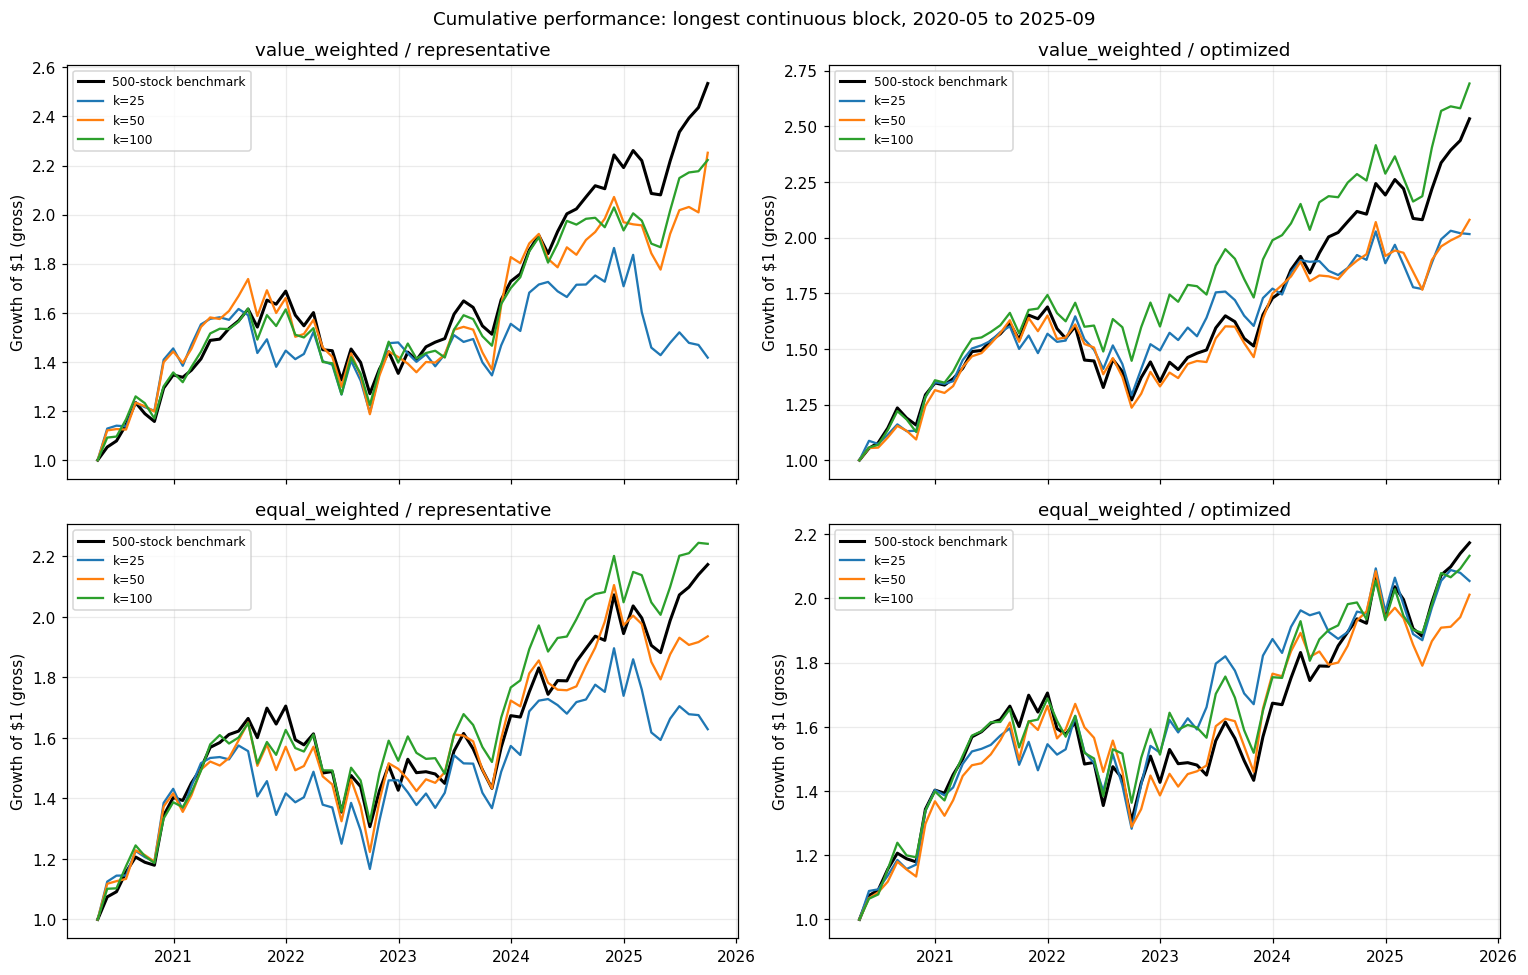

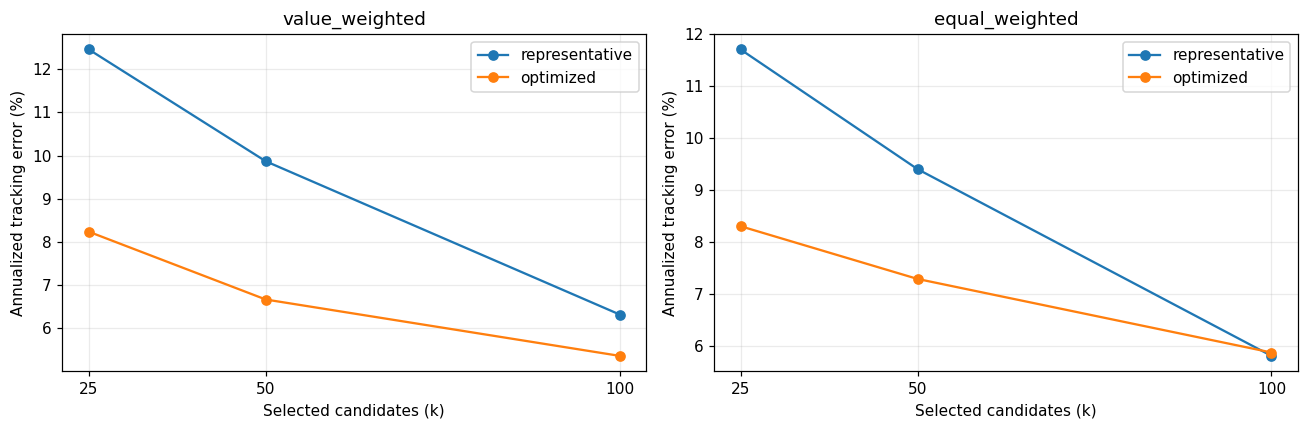

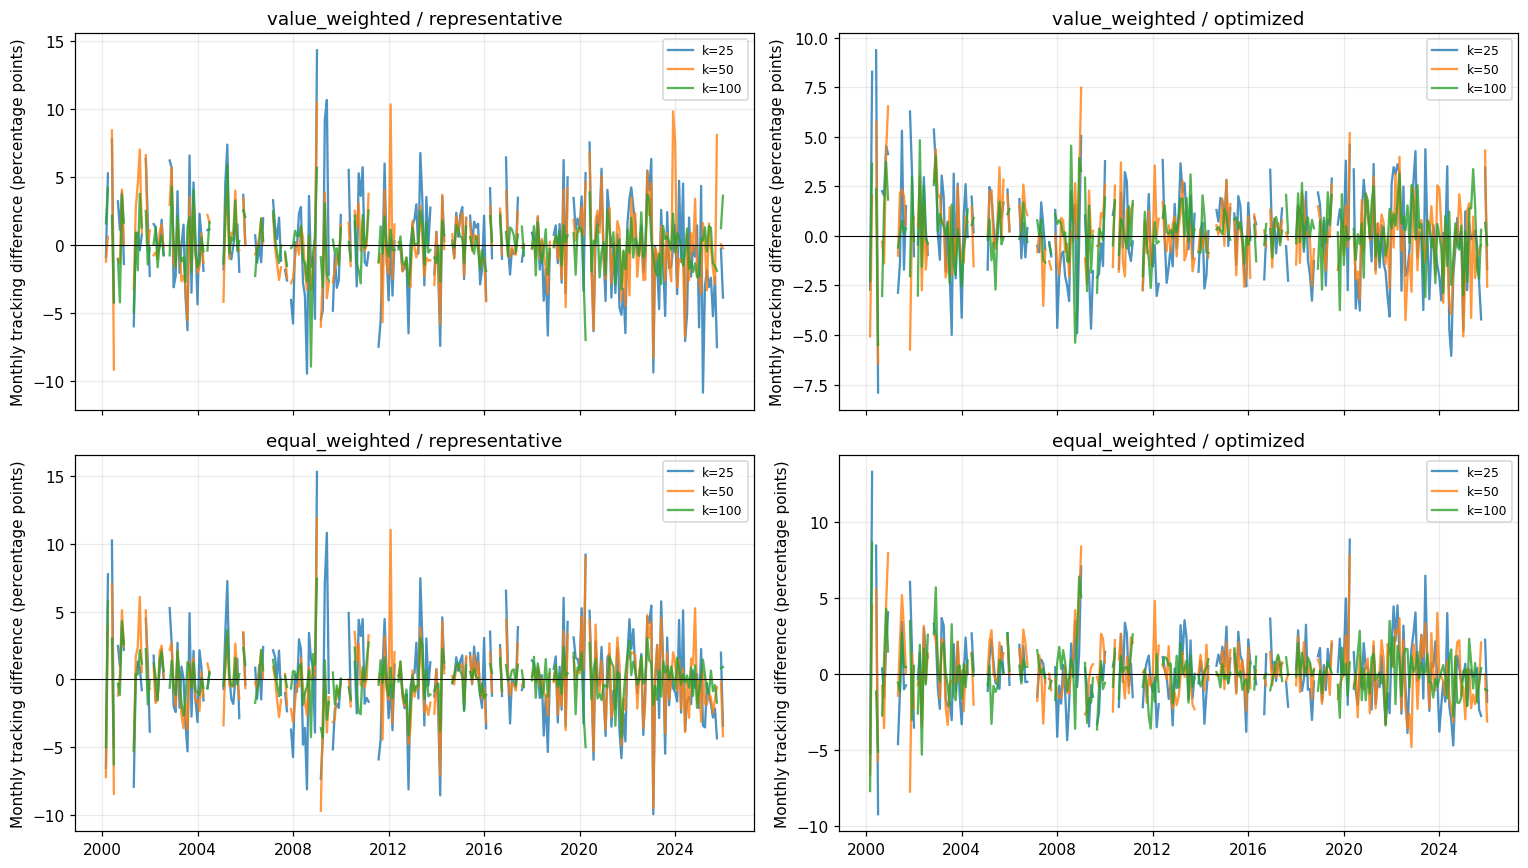

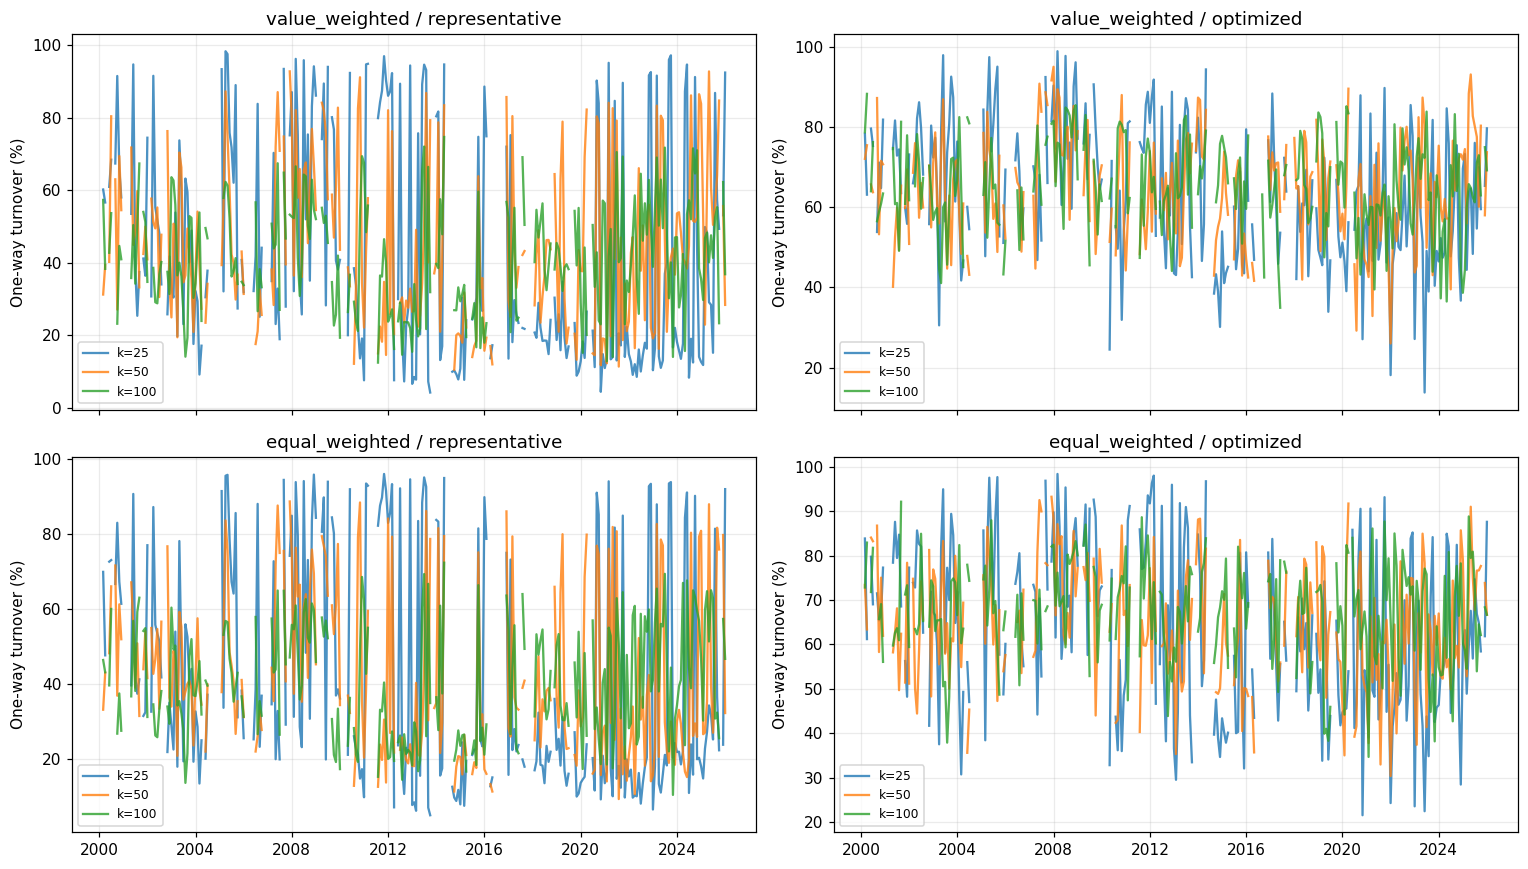

In [19]:
def plot_results(summary, curves, output_dir):
    # Calendar-based choice: do not select a block based on portfolio performance.
    lengths = curves.groupby("block")["holding_month"].nunique()
    longest_block = lengths.idxmax()
    block = curves.loc[curves["block"].eq(longest_block)]
    first, last = block["holding_month"].min(), block["holding_month"].max()
    figs = {}
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    for row, benchmark in enumerate(BENCHMARKS):
        for col, method in enumerate(METHODS):
            ax = axes[row, col]
            subset = block.loc[block["benchmark"].eq(benchmark) & block["method"].eq(method)]
            base = subset.loc[subset["k"].eq(K_VALUES[0])].sort_values("holding_month")
            # Include the initial dollar at the previous month-end.
            dates = pd.PeriodIndex([first - 1] + base["holding_month"].tolist()).to_timestamp("M")
            ax.plot(dates, np.r_[1.0, base["benchmark_wealth"]], color="black",
                    linewidth=2, label="500-stock benchmark")
            for k in K_VALUES:
                g = subset.loc[subset["k"].eq(k)].sort_values("holding_month")
                ax.plot(dates, np.r_[1.0, g["portfolio_wealth"]], label=f"k={k}")
            ax.set_title(f"{benchmark} / {method}")
            ax.set_ylabel("Growth of $1 (gross)")
            ax.legend(fontsize=8)
    fig.suptitle(f"Cumulative performance: longest continuous block, {first} to {last}")
    fig.tight_layout()
    figs["cumulative_returns"] = fig

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, benchmark in zip(axes, BENCHMARKS):
        for method in METHODS:
            g = summary.loc[summary["benchmark"].eq(benchmark) & summary["method"].eq(method)].sort_values("k")
            ax.plot(g["k"], 100 * g["tracking_error_annualized"], marker="o", label=method)
        ax.set(title=benchmark, xlabel="Selected candidates (k)",
               ylabel="Annualized tracking error (%)", xticks=list(K_VALUES))
        ax.legend()
    fig.tight_layout()
    figs["tracking_error_by_size"] = fig

    calendar = pd.period_range(curves["holding_month"].min(), curves["holding_month"].max(), freq="M")
    for field, label, filename in [
        ("active_return", "Monthly tracking difference (percentage points)", "tracking_differences"),
        ("turnover", "One-way turnover (%)", "turnover"),
    ]:
        fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
        for row, benchmark in enumerate(BENCHMARKS):
            for col, method in enumerate(METHODS):
                ax = axes[row, col]
                for k in K_VALUES:
                    g = curves.loc[curves["benchmark"].eq(benchmark) & curves["method"].eq(method)
                                   & curves["k"].eq(k)].set_index("holding_month")
                    values = g[field].reindex(calendar)
                    ax.plot(calendar.to_timestamp("M"), 100 * values, label=f"k={k}", alpha=0.8)
                ax.set_title(f"{benchmark} / {method}")
                ax.set_ylabel(label)
                if field == "active_return":
                    ax.axhline(0, color="black", linewidth=0.7)
                ax.legend(fontsize=8)
        fig.tight_layout()
        figs[filename] = fig
    for filename, fig in figs.items():
        fig.savefig(output_dir / f"{filename}.png", dpi=180, bbox_inches="tight")
    return figs

figures = plot_results(summary, curves, OUTPUT_DIR)
plt.show()

### Findings generated from the current run

The following tables and narrative answer how tracking changes with portfolio
size, whether optimized weights help out of sample, and what turnover and
coverage limitations remain. No performance figures are hard-coded.

In [20]:
# Build the concluding narrative from current results rather than hard-coded figures.
requested_count = len(coverage_by_month)
valid_count = int(panel["holding_month"].nunique())
excluded_dates = coverage_by_month.index[~coverage_by_month["included"]].astype(str).tolist()
longest_id = curves.groupby("block")["holding_month"].nunique().idxmax()
longest = curves.loc[curves["block"].eq(longest_id)]
te = summary.pivot(index=["benchmark", "k"], columns="method", values="tracking_error_annualized")
turn = summary.pivot(index=["benchmark", "k"], columns="method", values="mean_turnover")
optimized_wins = int((te["optimized"] < te["representative"]).sum())
higher_turnover = int((turn["optimized"] > turn["representative"]).sum())
monotone_groups = sum(
    group.sort_values("k")["tracking_error_annualized"].is_monotonic_decreasing
    for _, group in summary.groupby(["benchmark", "method"])
)
display(Markdown(
    f"**Evaluation coverage.** The requested period is **{START_HOLDING} through {END_HOLDING}**. "
    f"All {len(K_VALUES) * len(BENCHMARKS) * len(METHODS)} strategies are compared on **{valid_count} of {requested_count} months**, with "
    f"**{len(excluded_dates)} excluded months** detailed in the coverage audit. "
    f"The weighting stage uses the drop policy with at least {MIN_TRAINING_MONTHS} valid observations "
    f"inside each {LOOKBACK}-month window; the supplied portfolios use "
    f"{int(diagnostics['n_training_months'].min())}–{int(diagnostics['n_training_months'].max())} observations.\n\n"
    f"**Main findings.** Optimized weights have lower annualized out-of-sample tracking error "
    f"in **{optimized_wins} of {len(te)}** benchmark/size comparisons and higher mean turnover "
    f"in **{higher_turnover} of {len(turn)}** comparisons. Tracking error falls with increasing k "
    f"in **{monotone_groups} of {len(BENCHMARKS) * len(METHODS)}** benchmark/method combinations."
))
table = [
    "| Benchmark | Method | k | Annualized tracking error | Correlation | Mean monthly turnover |",
    "|---|---|---:|---:|---:|---:|",
]
for row in summary.sort_values(["benchmark", "k", "method"]).itertuples(index=False):
    table.append(
        f"| {row.benchmark.replace('_', ' ')} | {row.method} | {row.k} | "
        f"{row.tracking_error_annualized:.2%} | {row.correlation:.4f} | {row.mean_turnover:.2%} |"
    )
display(Markdown("\n".join(table)))
best_lines = []
for benchmark, group in summary.groupby("benchmark"):
    best = group.loc[group["tracking_error_annualized"].idxmin()]
    best_lines.append(
        f"For the **{benchmark.replace('_', ' ')}** benchmark, the lowest observed tracking error "
        f"is **{best['tracking_error_annualized']:.2%}** using **{best['method']} weights, "
        f"k = {int(best['k'])}**. Its annualized arithmetic mean tracking difference is "
        f"**{100 * best['mean_tracking_difference_annualized']:+.2f} percentage points**."
    )
display(Markdown("**Best replication by tracking error.**\n\n" + "\n\n".join(best_lines)))
display(Markdown(
    "**Interpretation and limitations.** The objective is benchmark replication. Lower tracking error "
    "measures closer monthly movements but does not guarantee identical cumulative values. "
    "Higher turnover may increase trading costs; all reported performance is gross of costs. "
    f"The common sample spans **{panel['block'].nunique()} continuous blocks**, and cumulative wealth "
    "restarts after each missing month. The main cumulative chart shows only the longest block, "
    f"**{longest['holding_month'].min()} through {longest['holding_month'].max()}** "
    f"({longest['holding_month'].nunique()} months); the block table reports all blocks. "
    "The estimates are conditional on available observations. Missing test returns must be resolved "
    "before presenting one continuous investment record for the entire requested period. "
))

**Evaluation coverage.** The requested period is **2000-01 through 2025-12**. All 12 strategies are compared on **259 of 312 months**, with **53 excluded months** detailed in the coverage audit. The weighting stage uses the drop policy with at least 36 valid observations inside each 60-month window; the supplied portfolios use 36–60 observations.

**Main findings.** Optimized weights have lower annualized out-of-sample tracking error in **5 of 6** benchmark/size comparisons and higher mean turnover in **6 of 6** comparisons. Tracking error falls with increasing k in **4 of 4** benchmark/method combinations.

| Benchmark | Method | k | Annualized tracking error | Correlation | Mean monthly turnover |
|---|---|---:|---:|---:|---:|
| equal weighted | optimized | 25 | 8.31% | 0.8781 | 63.18% |
| equal weighted | representative | 25 | 11.71% | 0.8285 | 41.95% |
| equal weighted | optimized | 50 | 7.30% | 0.9030 | 64.27% |
| equal weighted | representative | 50 | 9.41% | 0.8674 | 41.46% |
| equal weighted | optimized | 100 | 5.88% | 0.9382 | 67.10% |
| equal weighted | representative | 100 | 5.82% | 0.9432 | 40.16% |
| value weighted | optimized | 25 | 8.24% | 0.8680 | 63.51% |
| value weighted | representative | 25 | 12.46% | 0.8076 | 43.19% |
| value weighted | optimized | 50 | 6.67% | 0.9075 | 64.50% |
| value weighted | representative | 50 | 9.87% | 0.8613 | 44.77% |
| value weighted | optimized | 100 | 5.36% | 0.9445 | 64.69% |
| value weighted | representative | 100 | 6.32% | 0.9344 | 41.28% |

**Best replication by tracking error.**

For the **equal weighted** benchmark, the lowest observed tracking error is **5.82%** using **representative weights, k = 100**. Its annualized arithmetic mean tracking difference is **-0.20 percentage points**.

For the **value weighted** benchmark, the lowest observed tracking error is **5.36%** using **optimized weights, k = 100**. Its annualized arithmetic mean tracking difference is **+2.04 percentage points**.

**Interpretation and limitations.** The objective is benchmark replication. Lower tracking error measures closer monthly movements but does not guarantee identical cumulative values. Higher turnover may increase trading costs; all reported performance is gross of costs. The common sample spans **38 continuous blocks**, and cumulative wealth restarts after each missing month. The main cumulative chart shows only the longest block, **2020-05 through 2025-09** (65 months); the block table reports all blocks. The estimates are conditional on available observations. Missing test returns must be resolved before presenting one continuous investment record for the entire requested period. 

## Reproducibility record and submission

The record below saves the configuration, dependency versions, input fingerprints,
training and evaluation coverage, and output filenames. Source CSV hashes and
the displayed source mode distinguish a fresh WRDS extraction from a cached run.
Generated filenames may be overwritten by later runs in the same folder; the
manifest lists only outputs generated by this execution.

For the anonymous demo submission, upload **this notebook only**. Reviewers can
regenerate all intermediate files with their own WRDS account. Additional
precomputed CSVs and scripts are not needed. The separate anonymous slide deck
is a second deliverable under the assignment and is outside this notebook.

In [21]:
def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


suffix = f"{START_HOLDING}_to_{END_HOLDING}.csv"
current_outputs = [
    "source_history_coverage.csv", "cluster_selected_stocks.csv",
    f"monthly_weights_{suffix}", f"monthly_weight_diagnostics_{suffix}",
    f"benchmark_returns_{suffix}", "all_strategy_months.csv", "coverage_audit.csv",
    "invalid_held_stock_returns.csv", "excluded_training_observations.csv",
    "training_coverage.csv", "upstream_weight_diagnostics.csv", "coverage_by_month.csv",
    "missing_benchmark_constituents.csv", "summary_statistics.csv",
    "continuous_block_statistics.csv", "common_monthly_results.csv",
    "tracking_error_comparison.csv", "cumulative_returns.png",
    "tracking_error_by_size.png", "tracking_differences.png", "turnover.png",
]
if not all((OUTPUT_DIR / name).is_file() for name in current_outputs):
    raise ValueError("An expected current-run output was not created")
manifest = {
    "configuration": {
        "data_start": DATA_START, "data_end": DATA_END,
        "holding_start": START_HOLDING, "holding_end": END_HOLDING,
        "universe_size": N_STOCKS, "lookback": LOOKBACK, "k_values": list(K_VALUES),
        "minimum_training_months": MIN_TRAINING_MONTHS,
        "missing_benchmark_policy": MISSING_BENCHMARK,
        "objective": OBJECTIVE, "max_weight": MAX_WEIGHT, "ridge": RIDGE,
    },
    "source_mode": source_mode,
    "source_hashes": {path.name: file_sha256(path) for path in [formation_path, history_path]},
    "versions": {"python": platform.python_version(), "numpy": np.__version__,
                 "pandas": pd.__version__, "scipy": scipy.__version__,
                 "matplotlib": plt.matplotlib.__version__},
    "training_observations_min": int(diagnostics["n_training_months"].min()),
    "training_observations_max": int(diagnostics["n_training_months"].max()),
    "common_months": int(panel["holding_month"].nunique()),
    "excluded_months": int((~coverage_by_month["included"]).sum()),
    "continuous_blocks": int(panel["block"].nunique()),
    "return_units": "decimal monthly total returns, gross of costs",
    "turnover": "half-L1 vs prior drifted holdings; initial investment excluded",
    "realized_missing_policy": "invalidate; compare strategies on common dates",
    "outputs": current_outputs + ["run_manifest.json"],
}
(OUTPUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(f"Complete. Saved {len(current_outputs) + 1} tables, figures, and records to {OUTPUT_DIR.name}/")

Complete. Saved 22 tables, figures, and records to demo_output/
